# US 12 — Compare baseline models (Ridge vs Random Forest)

**Sprint 5** | Depends on US 10 + US 11 (`docs/modeling_spec.md`)

Run **Run All** from repo root or `notebooks/modeling/`.

**Inputs:** `reports/us10_linear_metrics.csv`, `reports/us11_tree_metrics.csv`

**Outputs:**
- `reports/us12_baseline_comparison.csv`
- `reports/figures/us12_metrics_comparison.png`
- `reports/us12_model_comparison_summary.txt`

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def _repo_root() -> Path:
    cwd = Path.cwd().resolve()
    if (cwd / "data" / "processed").is_dir():
        return cwd
    if cwd.name == "notebooks" and (cwd.parent / "data" / "processed").is_dir():
        return cwd.parent
    if cwd.name == "modeling" and (cwd.parent.parent / "data" / "processed").is_dir():
        return cwd.parent.parent
    return cwd


REPO_ROOT = _repo_root()
LINEAR_PATH = REPO_ROOT / "reports" / "us10_linear_metrics.csv"
TREE_PATH = REPO_ROOT / "reports" / "us11_tree_metrics.csv"
COMPARISON_PATH = REPO_ROOT / "reports" / "us12_baseline_comparison.csv"
FIG_PATH = REPO_ROOT / "reports" / "figures" / "us12_metrics_comparison.png"
SUMMARY_PATH = REPO_ROOT / "reports" / "us12_model_comparison_summary.txt"

print("Repo root:", REPO_ROOT)
print("Linear metrics:", LINEAR_PATH)
print("Tree metrics:", TREE_PATH)

Repo root: C:\Users\krish\Impact-of-Climate-Change-on-Energy-Demand
Linear metrics: C:\Users\krish\Impact-of-Climate-Change-on-Energy-Demand\reports\us10_linear_metrics.csv
Tree metrics: C:\Users\krish\Impact-of-Climate-Change-on-Energy-Demand\reports\us11_tree_metrics.csv


## Task 1 — Load US 10 and US 11 metrics CSVs

In [2]:
if not LINEAR_PATH.exists() or not TREE_PATH.exists():
    raise FileNotFoundError(
        "Missing metrics CSVs. Merge US 10 and US 11 to main before running US 12."
    )

linear = pd.read_csv(LINEAR_PATH)
tree = pd.read_csv(TREE_PATH)

print("Task 1 DONE")
print("US 10:", linear.shape)
print("US 11:", tree.shape)
linear

Task 1 DONE
US 10: (1, 4)
US 11: (1, 4)


,model,RMSE,MAE,R2
0,ridge_linear,4374.143277,1893.415381,0.459854


## Task 2 — Build combined comparison table

In [3]:
comparison = pd.concat([linear, tree], ignore_index=True)
comparison = comparison[["model", "RMSE", "MAE", "R2"]]

print("Task 2 DONE")
comparison

Task 2 DONE


,model,RMSE,MAE,R2
0,ridge_linear,4374.143277,1893.415381,0.459854
1,random_forest,2428.830195,859.851557,0.833460


## Task 3 — Print side-by-side comparison

In [4]:
print("Task 3 DONE — test-set metrics (2019–2022 holdout)")
print(comparison.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

best_rmse = comparison.loc[comparison["RMSE"].idxmin(), "model"]
best_r2 = comparison.loc[comparison["R2"].idxmax(), "model"]
print(f"\nLower RMSE: {best_rmse}")
print(f"Higher R²: {best_r2}")

Task 3 DONE — test-set metrics (2019–2022 holdout)
        model      RMSE       MAE     R2
 ridge_linear 4374.1433 1893.4154 0.4599
random_forest 2428.8302  859.8516 0.8335

Lower RMSE: random_forest
Higher R²: random_forest


## Task 4 — Plot metrics comparison chart

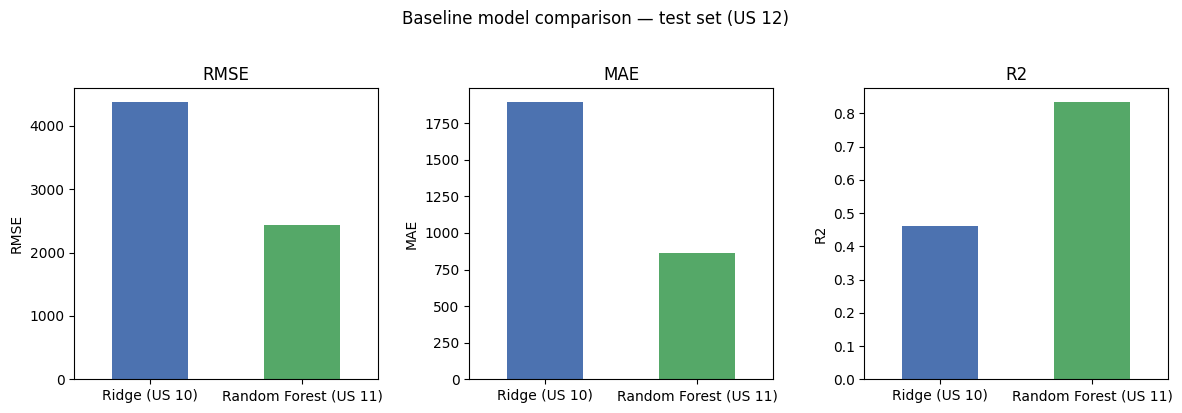

Task 4 DONE — saved: C:\Users\krish\Impact-of-Climate-Change-on-Energy-Demand\reports\figures\us12_metrics_comparison.png


In [5]:
FIG_PATH.parent.mkdir(parents=True, exist_ok=True)

plot_df = comparison.set_index("model")[["RMSE", "MAE", "R2"]]
labels = {"ridge_linear": "Ridge (US 10)", "random_forest": "Random Forest (US 11)"}
plot_df.index = [labels.get(m, m) for m in plot_df.index]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
colors = ["#4C72B0", "#55A868"]

for ax, metric in zip(axes, ["RMSE", "MAE", "R2"]):
    plot_df[metric].plot(kind="bar", ax=ax, color=colors, rot=0)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.set_ylabel(metric)

fig.suptitle("Baseline model comparison — test set (US 12)", y=1.02)
plt.tight_layout()
fig.savefig(FIG_PATH, dpi=120, bbox_inches="tight")
plt.show()

print("Task 4 DONE — saved:", FIG_PATH)

## Task 5 — Write short results summary

In [6]:
ridge = comparison.loc[comparison["model"] == "ridge_linear"].iloc[0]
rf = comparison.loc[comparison["model"] == "random_forest"].iloc[0]

summary_lines = [
    "US 12 — BASELINE MODEL COMPARISON SUMMARY",
    "=" * 60,
    "",
    "Setup:",
    "- Same train/test split as US 9 (train 2001–2018, test 2019–2022)",
    "- Target: electricity_demand_per_capita",
    "- Six features per docs/modeling_spec.md",
    "",
    "Test metrics:",
    f"- Ridge (US 10): RMSE={ridge['RMSE']:.2f}, MAE={ridge['MAE']:.2f}, R²={ridge['R2']:.4f}",
    f"- Random Forest (US 11): RMSE={rf['RMSE']:.2f}, MAE={rf['MAE']:.2f}, R²={rf['R2']:.4f}",
    "",
    "Findings:",
    "1. Random Forest outperforms Ridge on all three test metrics.",
    "2. Ridge is a simpler linear baseline; tree model captures non-linear patterns better.",
    "3. US 11 feature importance: co2_per_capita and electricity mix shares ranked highest.",
    "4. temperature_change_c had low importance in the pooled Random Forest model.",
    "",
    "Caveat:",
    "- Results are predictive/associative, not causal (see docs/modeling_spec.md).",
    "- Pooled global models do not control for country fixed effects.",
]

SUMMARY_PATH.parent.mkdir(parents=True, exist_ok=True)
SUMMARY_PATH.write_text("\n".join(summary_lines) + "\n", encoding="utf-8")

print("Task 5 DONE — saved:", SUMMARY_PATH)
print()
print(SUMMARY_PATH.read_text(encoding="utf-8"))

Task 5 DONE — saved: C:\Users\krish\Impact-of-Climate-Change-on-Energy-Demand\reports\us12_model_comparison_summary.txt

US 12 — BASELINE MODEL COMPARISON SUMMARY

Setup:
- Same train/test split as US 9 (train 2001–2018, test 2019–2022)
- Target: electricity_demand_per_capita
- Six features per docs/modeling_spec.md

Test metrics:
- Ridge (US 10): RMSE=4374.14, MAE=1893.42, R²=0.4599
- Random Forest (US 11): RMSE=2428.83, MAE=859.85, R²=0.8335

Findings:
1. Random Forest outperforms Ridge on all three test metrics.
2. Ridge is a simpler linear baseline; tree model captures non-linear patterns better.
3. US 11 feature importance: co2_per_capita and electricity mix shares ranked highest.
4. temperature_change_c had low importance in the pooled Random Forest model.

Caveat:
- Results are predictive/associative, not causal (see docs/modeling_spec.md).
- Pooled global models do not control for country fixed effects.



## Task 6 — Save combined comparison CSV

In [7]:
COMPARISON_PATH.parent.mkdir(parents=True, exist_ok=True)
comparison.to_csv(COMPARISON_PATH, index=False)

print("Task 6 DONE — saved:", COMPARISON_PATH)
print("US 12 complete.")

Task 6 DONE — saved: C:\Users\krish\Impact-of-Climate-Change-on-Energy-Demand\reports\us12_baseline_comparison.csv
US 12 complete.
